In [2]:
import torch as t
import matplotlib.pyplot as plt
import math

from sometria.architecture.scheduler import lr_schedule

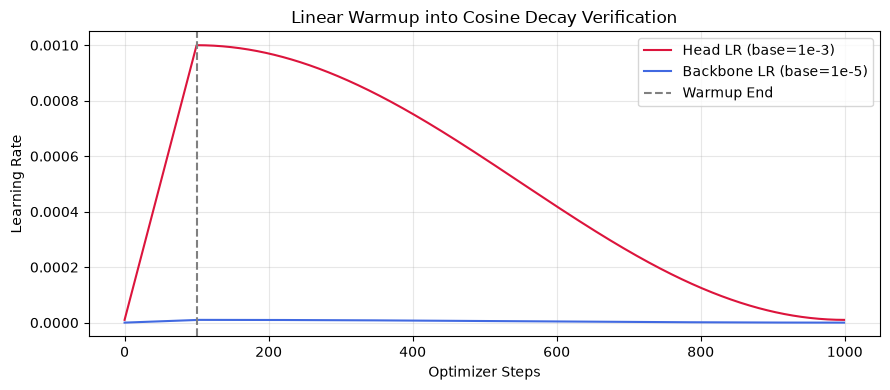

In [3]:
# Dummy test setup with 2 different parameter groups (Finetuning setting)
model = t.nn.Linear(10, 10)
optimizer = t.optim.AdamW([
    {"params": model.weight, "lr": 1e-3},  # Head
    {"params": model.bias,   "lr": 1e-5},  # Backbone
])

warmup = 0.10
total_steps = 1000
warmup_steps = int(total_steps * warmup)

scheduler = lr_schedule(optimizer, warmup_steps=warmup_steps, total_steps=total_steps, min_factor=0.01)

lrs_head = []
lrs_backbone = []

for step in range(total_steps):
    lrs_head.append(optimizer.param_groups[0]["lr"])
    lrs_backbone.append(optimizer.param_groups[1]["lr"])
    optimizer.step()
    scheduler.step()

# Plot learning rate curves
plt.figure(figsize=(9, 4))
plt.plot(lrs_head, label="Head LR (base=1e-3)", color="crimson")
plt.plot(lrs_backbone, label="Backbone LR (base=1e-5)", color="royalblue")
plt.axvline(x=warmup_steps, color="gray", linestyle="--", label="Warmup End")
plt.xlabel("Optimizer Steps")
plt.ylabel("Learning Rate")
plt.title("Linear Warmup into Cosine Decay Verification")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()